# Lesson 1: The Lay of the Land

Welcome to machine learning.

Over the next weeks, you'll go from "I've heard of ML" to building and deploying real models. You'll understand what's happening inside neural networks, when to use trees vs deep learning, and how to work with modern LLMs.

But first, let's get oriented. This lesson answers the big questions:

- What *is* machine learning?
- What types of problems can it solve?
- What tools and techniques exist?
- Where is this course taking us?

We'll see working demos, introduce the core vocabulary, and build a mental map of the field. Don't worry about understanding everything deeply yet — that's what the rest of the course is for.

In [1]:
# === VISUALIZATION HELPERS (collapsed) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

def plot_ml_types():
    """Visual comparison of regression, classification, and clustering."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Regression
    np.random.seed(42)
    x = np.linspace(0, 10, 50)
    y = 2*x + 1 + np.random.normal(0, 2, 50)
    axes[0].scatter(x, y, alpha=0.6)
    axes[0].plot(x, 2*x + 1, 'r-', linewidth=2, label='Learned pattern')
    axes[0].set_title('REGRESSION\nPredict a number', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Input (e.g., house size)')
    axes[0].set_ylabel('Output (e.g., price)')
    axes[0].legend()
    
    # Classification
    X_class, y_class = make_blobs(n_samples=100, centers=2, random_state=42)
    colors = ['#e74c3c' if label == 0 else '#3498db' for label in y_class]
    axes[1].scatter(X_class[:, 0], X_class[:, 1], c=colors, alpha=0.6)
    axes[1].axline((0, 2), slope=0.5, color='green', linewidth=2, label='Decision boundary')
    axes[1].set_title('CLASSIFICATION\nPredict a category', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Feature 1')
    axes[1].set_ylabel('Feature 2')
    axes[1].legend()
    
    # Clustering
    X_clust, _ = make_blobs(n_samples=150, centers=3, random_state=42)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_clust)
    axes[2].scatter(X_clust[:, 0], X_clust[:, 1], c=kmeans.labels_, cmap='viridis', alpha=0.6)
    axes[2].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
                   c='red', marker='X', s=200, label='Cluster centers')
    axes[2].set_title('CLUSTERING (Unsupervised)\nFind groups', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Feature 1')
    axes[2].set_ylabel('Feature 2')
    axes[2].legend()
    
    plt.tight_layout()
    return fig

def plot_image_grid(images, titles, figsize=(16, 4)):
    """Display a row of images with titles."""
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(title, fontsize=10)
    plt.tight_layout()
    return fig

print("Visualization helpers loaded!")

Visualization helpers loaded!


## Part 1: What is Machine Learning?

### Traditional Programming vs Machine Learning

In traditional programming, you write explicit rules:

```python
# Traditional approach
def is_spam(email):
    spam_words = ['viagra', 'lottery', 'prince', 'urgent']
    for word in spam_words:
        if word in email.lower():
            return True
    return False
```

This works until spammers change tactics. You're stuck playing whack-a-mole, adding rules forever.

**Machine learning flips this around:**

```
Traditional:  Rules + Data → Answers
ML:           Data + Answers → Rules (learned automatically)
```

Instead of writing rules, you show the algorithm examples:
- "Here are 10,000 emails. These 2,000 are spam. These 8,000 aren't."
- "Figure out the pattern yourself."

The algorithm finds rules you never would have thought of — patterns in word frequency, sender behavior, timing, formatting. And when spammers change tactics, you just retrain on new examples.

### The Core Idea

At its heart, machine learning is:

> **Learning patterns from data to make predictions or decisions.**

A model starts with random guesses. You show it examples with correct answers. It adjusts its internal numbers (called **parameters** or **weights**) to make better predictions. After seeing enough examples, it can generalize to new data it's never seen.

This process of adjusting parameters based on examples is called **training**. Using the trained model on new data is called **inference**.

## Part 2: Types of Machine Learning

Not all ML problems are the same. Here's the landscape:

### Supervised Learning

You have labeled data: inputs paired with correct outputs.

| Input | Output (Label) |
|-------|----------------|
| Email text | Spam / Not spam |
| House features | Price |
| Medical image | Disease / Healthy |

The model learns the mapping from inputs to outputs. This is the most common type and the focus of this course.

**Two flavors:**
- **Classification**: Output is a category (spam/not spam, cat/dog/bird)
- **Regression**: Output is a number (price, temperature, probability)

### Unsupervised Learning

You have data without labels. The model finds patterns on its own.

- **Clustering**: Group similar items (customer segments, document topics)
- **Dimensionality reduction**: Compress data while preserving structure (PCA, t-SNE)
- **Anomaly detection**: Find unusual patterns (fraud, defects)

We won't focus on this, but you should know it exists.

### Reinforcement Learning

An agent learns by taking actions and receiving rewards. Think game-playing AI (AlphaGo) or robotics.

We won't cover this in this course.

### Self-Supervised Learning

The model creates its own labels from the data. This is how modern LLMs are trained:
- "Given these words, predict the next word"
- The "labels" come from the text itself

We'll work with LLMs in the later part of the course.

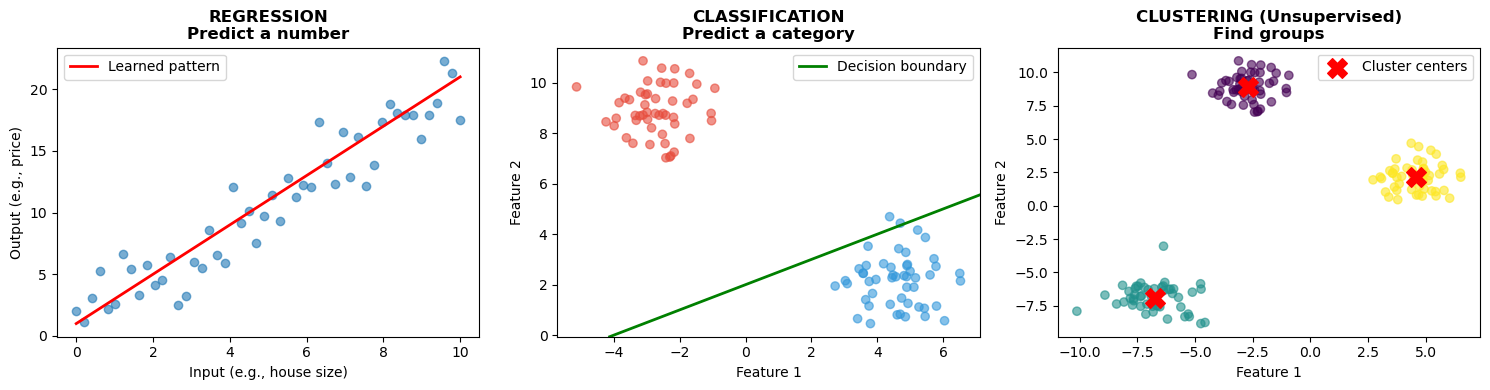

This course focuses on SUPERVISED LEARNING (regression and classification)


In [2]:
# Visual comparison of ML problem types
plot_ml_types()
plt.show()

print("This course focuses on SUPERVISED LEARNING (regression and classification)")

## Part 3: Types of Data

ML models work on different types of data, each with their own techniques:

### Tabular Data
Spreadsheet-like data with rows (samples) and columns (features).
- Customer records, medical data, financial transactions
- **Best tools**: Tree-based models (Random Forest, XGBoost), sometimes neural networks

### Images
Grids of pixel values.
- Photos, medical scans, satellite imagery
- **Best tools**: Convolutional Neural Networks (CNNs), Vision Transformers

### Text
Sequences of words/characters.
- Documents, emails, reviews, code
- **Best tools**: Transformers, LLMs (GPT, Claude, BERT)

### Time Series
Sequential data over time.
- Stock prices, sensor readings, weather
- **Best tools**: RNNs, Transformers, specialized methods

### Audio
Sound waveforms.
- Speech, music, environmental sounds
- **Best tools**: CNNs on spectrograms, specialized architectures

**This course focuses on tabular data and images**, then moves to working with text via LLM APIs.

## Part 4: Types of Models

Different algorithms for learning patterns:

### Linear Models
The simplest: weighted sum of features.
- **Linear Regression**: Predict numbers
- **Logistic Regression**: Predict categories (despite the name!)
- Fast, interpretable, but limited to linear patterns

### Tree-Based Models
Make decisions via a series of yes/no questions.
- **Decision Trees**: Single tree, interpretable but overfits
- **Random Forests**: Many trees averaged together
- **Gradient Boosting** (XGBoost, LightGBM): Trees that learn from each other's mistakes
- Often the best choice for tabular data!

### Neural Networks
Layers of interconnected "neurons" that learn hierarchical patterns.
- **MLPs** (Multi-Layer Perceptrons): Fully connected layers, good for tabular
- **CNNs** (Convolutional Neural Networks): Designed for images
- **RNNs** (Recurrent Neural Networks): Designed for sequences (largely replaced by Transformers)
- **Transformers**: Attention-based, power modern LLMs

### The Zoo of Algorithms

There are many more (SVM, KNN, Naive Bayes, etc.), but the above cover 90% of practical use cases today.

In [3]:
# Let's see these models in action on the same problem
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Classic Iris dataset: classify flower species from petal/sepal measurements
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(
    iris.data, iris.target, test_size=0.3, random_state=42
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Neural Network (MLP)': MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)
}

print("Model Comparison on Iris Dataset")
print("="*50)
print(f"Task: Classify 3 species of iris flowers")
print(f"Features: sepal length/width, petal length/width")
print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
print("\nResults:")
print("-"*50)

for name, model in models.items():
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    print(f"{name:25s} → {accuracy:.1%} accuracy")

print("\nAll models do well on this simple dataset!")
print("Differences show up on harder, larger datasets.")

Model Comparison on Iris Dataset
Task: Classify 3 species of iris flowers
Features: sepal length/width, petal length/width
Training samples: 105, Test samples: 45

Results:
--------------------------------------------------
Logistic Regression       → 100.0% accuracy
Decision Tree             → 100.0% accuracy


Random Forest             → 100.0% accuracy
Neural Network (MLP)      → 97.8% accuracy

All models do well on this simple dataset!
Differences show up on harder, larger datasets.


## Part 5: The ML Workflow

Every ML project follows the same general pattern:

```
1. UNDERSTAND THE PROBLEM
   What are you trying to predict?
   What data do you have?
   How will success be measured?
         ↓
2. PREPARE THE DATA
   Clean: handle missing values, outliers
   Transform: normalize, encode categories
   Split: training set vs validation set vs test set
         ↓
3. TRAIN A MODEL
   Choose an algorithm
   Feed it training data
   Model learns patterns (adjusts weights)
         ↓
4. EVALUATE
   Test on held-out data
   Measure metrics (accuracy, loss, etc.)
   Is it good enough?
         ↓
5. ITERATE
   Try different models
   Tune hyperparameters
   Engineer better features
         ↓
6. DEPLOY
   Put model into production
   Monitor performance
   Retrain as needed
```

This course will take you through all of these steps.

## Part 6: ML in Action

Let's see machine learning solve real problems. We'll go through each demo step by step.

### Demo 1: Tabular Data — Predicting Titanic Survival

The Titanic sank on April 15, 1912. Of ~2,200 people aboard, over 1,500 died. But survival wasn't random — it depended heavily on factors like gender, ticket class, and age.

**The question:** Given information about a passenger, can we predict whether they survived?

This is a **binary classification** problem: two possible outcomes (survived or died).

In [4]:
# Step 1: Load the data
titanic = pd.read_csv('/data/datasets/titanic/titanic.csv')

print("Titanic Dataset")
print("="*60)
print(f"Total passengers: {len(titanic)}")
print(f"Survived: {titanic['Survived'].sum()} ({titanic['Survived'].mean():.1%})")
print(f"Died: {(titanic['Survived']==0).sum()} ({(titanic['Survived']==0).mean():.1%})")
print(f"\nColumns available:")
for col in titanic.columns:
    print(f"  • {col}")

Titanic Dataset
Total passengers: 891
Survived: 342 (38.4%)
Died: 549 (61.6%)

Columns available:
  • PassengerId
  • Survived
  • Pclass
  • Name
  • Sex
  • Age
  • SibSp
  • Parch
  • Ticket
  • Fare
  • Cabin
  • Embarked


In [5]:
# Step 2: Look at the actual data
titanic.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


#### Exploring Patterns in the Data

Before training a model, let's see if there are obvious patterns. What factors are associated with survival?

In [6]:
# Step 3: Explore survival rates by different factors
print("Survival Rates by Category")
print("="*60)

# By gender
print("\nBy Gender:")
for sex in ['female', 'male']:
    rate = titanic[titanic['Sex'] == sex]['Survived'].mean()
    count = len(titanic[titanic['Sex'] == sex])
    print(f"  {sex.capitalize():10s}: {rate:5.1%} survived ({count} passengers)")

# By class
print("\nBy Ticket Class:")
for pclass in [1, 2, 3]:
    rate = titanic[titanic['Pclass'] == pclass]['Survived'].mean()
    count = len(titanic[titanic['Pclass'] == pclass])
    print(f"  Class {pclass}:    {rate:5.1%} survived ({count} passengers)")

# By age group
print("\nBy Age Group:")
titanic_with_age = titanic.dropna(subset=['Age'])
for label, (low, high) in [('Children (0-12)', (0, 12)), ('Teens (13-19)', (13, 19)), 
                            ('Adults (20-50)', (20, 50)), ('Elderly (50+)', (50, 100))]:
    mask = (titanic_with_age['Age'] >= low) & (titanic_with_age['Age'] < high)
    subset = titanic_with_age[mask]
    if len(subset) > 0:
        rate = subset['Survived'].mean()
        print(f"  {label:15s}: {rate:5.1%} survived ({len(subset)} passengers)")

Survival Rates by Category

By Gender:
  Female    : 74.2% survived (314 passengers)
  Male      : 18.9% survived (577 passengers)

By Ticket Class:
  Class 1:    63.0% survived (216 passengers)
  Class 2:    47.3% survived (184 passengers)
  Class 3:    24.2% survived (491 passengers)

By Age Group:
  Children (0-12): 57.4% survived (68 passengers)
  Teens (13-19)  : 42.9% survived (70 passengers)
  Adults (20-50) : 38.7% survived (476 passengers)
  Elderly (50+)  : 36.5% survived (74 passengers)


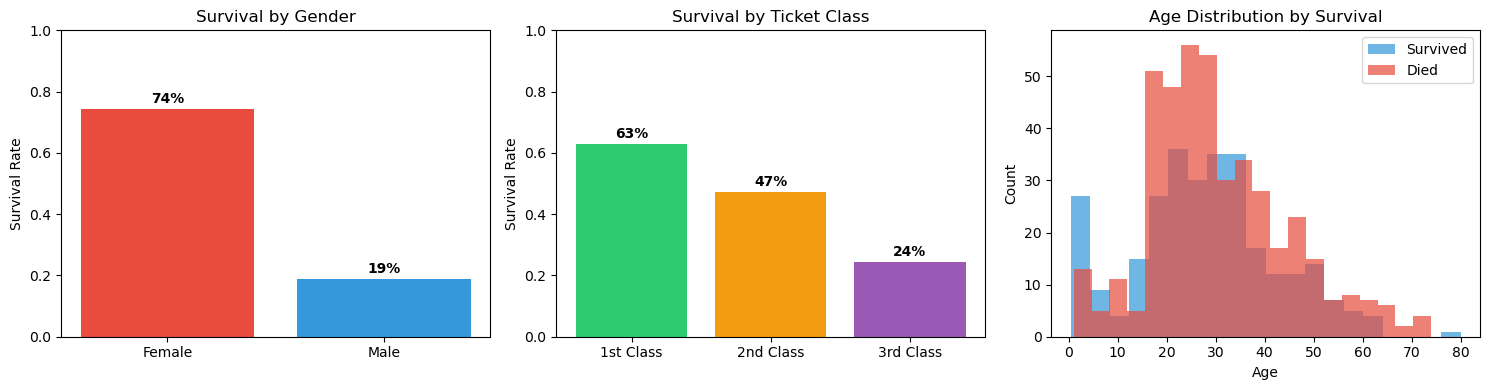


Key patterns:
• Women survived at much higher rates than men
• Higher class = higher survival rate
• Children had better chances (visible in age distribution)


In [7]:
# Step 4: Visualize survival patterns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Survival by gender
survival_by_sex = titanic.groupby('Sex')['Survived'].mean()
axes[0].bar(['Female', 'Male'], [survival_by_sex['female'], survival_by_sex['male']], 
           color=['#e74c3c', '#3498db'])
axes[0].set_ylabel('Survival Rate')
axes[0].set_title('Survival by Gender')
axes[0].set_ylim(0, 1)
for i, v in enumerate([survival_by_sex['female'], survival_by_sex['male']]):
    axes[0].text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')

# Survival by class
survival_by_class = titanic.groupby('Pclass')['Survived'].mean()
axes[1].bar(['1st Class', '2nd Class', '3rd Class'], survival_by_class.values,
           color=['#2ecc71', '#f39c12', '#9b59b6'])
axes[1].set_ylabel('Survival Rate')
axes[1].set_title('Survival by Ticket Class')
axes[1].set_ylim(0, 1)
for i, v in enumerate(survival_by_class.values):
    axes[1].text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')

# Age distribution
axes[2].hist(titanic[titanic['Survived']==1]['Age'].dropna(), bins=20, alpha=0.7, label='Survived', color='#3498db')
axes[2].hist(titanic[titanic['Survived']==0]['Age'].dropna(), bins=20, alpha=0.7, label='Died', color='#e74c3c')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Count')
axes[2].set_title('Age Distribution by Survival')
axes[2].legend()

plt.tight_layout()
plt.show()

print("\nKey patterns:")
print("• Women survived at much higher rates than men")
print("• Higher class = higher survival rate")
print("• Children had better chances (visible in age distribution)")

#### Training a Model

Now let's train a model to automatically learn these patterns. We'll use a **Random Forest** — a powerful algorithm that works well on tabular data.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Step 5: Prepare the data
# Select features we want to use
features = ['Pclass', 'Sex', 'Age', 'Fare', 'SibSp', 'Parch']

# Create a copy and handle preprocessing
df = titanic[features + ['Survived']].copy()

# Convert Sex to numbers (models need numbers, not text)
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})

# Drop rows with missing values (we'll learn better strategies later)
df = df.dropna()

# Split into features (X) and target (y)
X = df[features]
y = df['Survived']

print(f"Features: {features}")
print(f"Samples with complete data: {len(X)}")
print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features: ['Pclass', 'Sex', 'Age', 'Fare', 'SibSp', 'Parch']
Samples with complete data: 714

Feature matrix shape: (714, 6)
Target shape: (714,)


In [9]:
# Step 6: Split into training and test sets
# The model learns from training data; we evaluate on test data it hasn't seen
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data Split:")
print(f"  Training set: {len(X_train)} passengers (80%)")
print(f"  Test set:     {len(X_test)} passengers (20%)")
print(f"\nThe model will learn from {len(X_train)} examples,")
print(f"then we'll check how well it predicts the other {len(X_test)}.")

Data Split:
  Training set: 571 passengers (80%)
  Test set:     143 passengers (20%)

The model will learn from 571 examples,
then we'll check how well it predicts the other 143.


In [10]:
# Step 7: Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")
print(f"\nRandom Forest with {model.n_estimators} decision trees")
print(f"Each tree learned different patterns from the data.")

Model trained!

Random Forest with 100 decision trees
Each tree learned different patterns from the data.


In [11]:
# Step 8: Evaluate the model
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

print("Model Performance")
print("="*50)
print(f"Training accuracy: {train_accuracy:.1%}")
print(f"Test accuracy:     {test_accuracy:.1%}")
print(f"\nThe model correctly predicts survival for {test_accuracy:.0%} of passengers it hasn't seen!")

# Confusion matrix
cm = confusion_matrix(y_test, test_predictions)
print(f"\nConfusion Matrix:")
print(f"                  Predicted")
print(f"                  Died    Survived")
print(f"Actual Died       {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"       Survived   {cm[1,0]:4d}      {cm[1,1]:4d}")

Model Performance
Training accuracy: 99.1%
Test accuracy:     76.9%

The model correctly predicts survival for 77% of passengers it hasn't seen!

Confusion Matrix:
                  Predicted
                  Died    Survived
Actual Died         70        17
       Survived     16        40


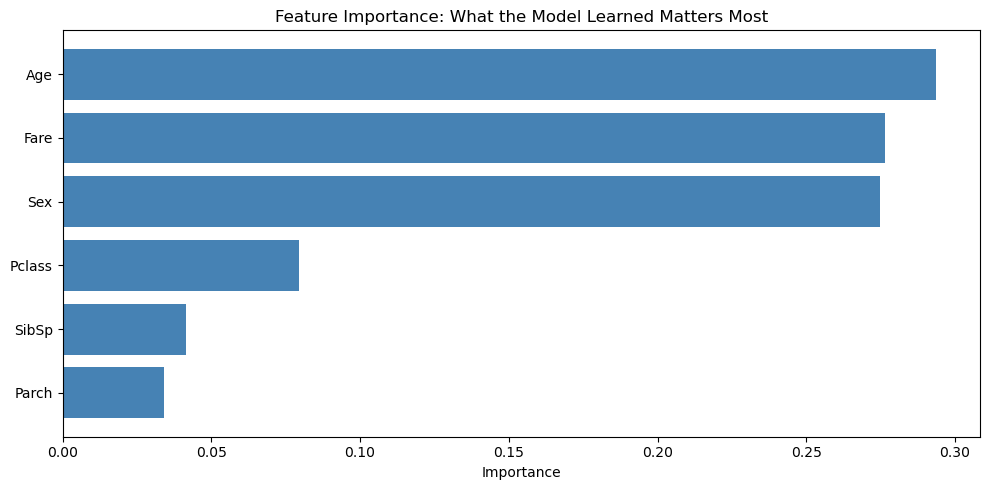

The model discovered:
• Sex is the most important factor (women first!)
• Fare/Class indicate wealth and cabin location
• Age matters (children prioritized)


In [12]:
# Step 9: What did the model learn?
# Feature importance tells us which factors mattered most

importances = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importances['Feature'], importances['Importance'], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Feature Importance: What the Model Learned Matters Most')
plt.tight_layout()
plt.show()

print("The model discovered:")
print("• Sex is the most important factor (women first!)")
print("• Fare/Class indicate wealth and cabin location")
print("• Age matters (children prioritized)")

In [13]:
# Step 10: Make predictions for hypothetical passengers
print("Predictions for Hypothetical Passengers")
print("="*60)

test_cases = [
    {'Pclass': 1, 'Sex': 0, 'Age': 25, 'Fare': 100, 'SibSp': 0, 'Parch': 0, 
     'desc': 'Young woman, 1st class, traveling alone'},
    {'Pclass': 3, 'Sex': 1, 'Age': 25, 'Fare': 8, 'SibSp': 0, 'Parch': 0,
     'desc': 'Young man, 3rd class, traveling alone'},
    {'Pclass': 2, 'Sex': 0, 'Age': 8, 'Fare': 25, 'SibSp': 1, 'Parch': 2,
     'desc': 'Girl, 2nd class, with family'},
    {'Pclass': 1, 'Sex': 1, 'Age': 55, 'Fare': 150, 'SibSp': 1, 'Parch': 0,
     'desc': 'Older man, 1st class, with spouse'},
    {'Pclass': 3, 'Sex': 0, 'Age': 30, 'Fare': 15, 'SibSp': 0, 'Parch': 2,
     'desc': 'Woman, 3rd class, with 2 children'},
]

for case in test_cases:
    X_new = pd.DataFrame([{k: v for k, v in case.items() if k != 'desc'}])
    prob = model.predict_proba(X_new)[0][1]
    prediction = 'SURVIVES' if prob >= 0.5 else 'DIES'
    
    print(f"\n{case['desc']}")
    print(f"  → Prediction: {prediction}")
    print(f"  → Probability of survival: {prob:.0%}")

Predictions for Hypothetical Passengers

Young woman, 1st class, traveling alone
  → Prediction: SURVIVES
  → Probability of survival: 99%

Young man, 3rd class, traveling alone
  → Prediction: DIES
  → Probability of survival: 1%

Girl, 2nd class, with family
  → Prediction: SURVIVES
  → Probability of survival: 97%

Older man, 1st class, with spouse
  → Prediction: DIES
  → Probability of survival: 35%

Woman, 3rd class, with 2 children
  → Prediction: SURVIVES
  → Probability of survival: 78%


#### Tabular ML Summary

We just followed the standard ML workflow:
1. **Load data** — understand what we're working with
2. **Explore** — find patterns before modeling
3. **Prepare** — clean data, encode categories, handle missing values
4. **Split** — separate training and test data
5. **Train** — fit the model to training data
6. **Evaluate** — test on held-out data
7. **Interpret** — understand what the model learned
8. **Predict** — use the model on new data

This same workflow applies to any tabular ML problem.

### Demo 2: Image Classification

Now something completely different: teaching a computer to recognize what's in a photo.

**The key insight:** To a computer, an image is just a grid of numbers. Each pixel has values for red, green, and blue intensity. A 224×224 image has 224 × 224 × 3 = 150,528 numbers.

How do you go from 150,000 numbers to "this is a dog"? That's what neural networks learn to do.

What the Computer Sees
Image dimensions: 500 × 400 pixels
Color channels: 3 (Red, Green, Blue)
Total numbers: 600,000

Pixel values range from 0 (dark) to 255 (bright)


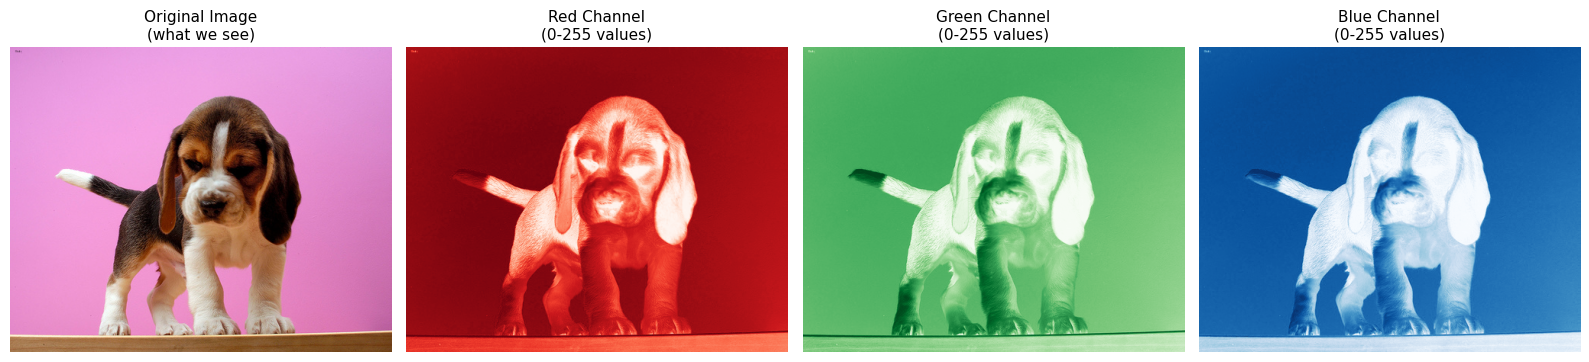


A small patch of pixel values (top-left 5×5, red channel):
[[216 218 218 216 217]
 [217 217 217 216 216]
 [217 218 215 217 215]
 [218 218 218 218 218]
 [212 217 217 220 219]]


In [14]:
from PIL import Image
import os

# Step 1: What does a computer "see"?
sample_image_path = '/data/datasets/oxford_pets/images/beagle_1.jpg'
img = Image.open(sample_image_path)
img_array = np.array(img)

print("What the Computer Sees")
print("="*50)
print(f"Image dimensions: {img.size[0]} × {img.size[1]} pixels")
print(f"Color channels: 3 (Red, Green, Blue)")
print(f"Total numbers: {img_array.size:,}")
print(f"\nPixel values range from 0 (dark) to 255 (bright)")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Original image
axes[0].imshow(img)
axes[0].set_title('Original Image\n(what we see)', fontsize=11)
axes[0].axis('off')

# Red channel
axes[1].imshow(img_array[:,:,0], cmap='Reds')
axes[1].set_title('Red Channel\n(0-255 values)', fontsize=11)
axes[1].axis('off')

# Green channel
axes[2].imshow(img_array[:,:,1], cmap='Greens')
axes[2].set_title('Green Channel\n(0-255 values)', fontsize=11)
axes[2].axis('off')

# Blue channel
axes[3].imshow(img_array[:,:,2], cmap='Blues')
axes[3].set_title('Blue Channel\n(0-255 values)', fontsize=11)
axes[3].axis('off')

plt.tight_layout()
plt.show()

print("\nA small patch of pixel values (top-left 5×5, red channel):")
print(img_array[:5, :5, 0])

#### Using a Pre-Trained Model

Training an image classifier from scratch requires millions of images and days of compute time. Instead, we'll use **transfer learning**: take a model someone else trained and apply it to our problem.

**ResNet-50** was trained on ImageNet — 1.2 million images across 1,000 categories. It already knows how to recognize edges, textures, shapes, and many objects. We can use this knowledge directly.

In [15]:
import torch
from torchvision import models, transforms
import urllib.request

# Step 2: Load the pre-trained model
model_resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model_resnet.eval()  # Set to evaluation mode

# Load ImageNet class labels
labels_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
labels_path = "/tmp/imagenet_classes.txt"
if not os.path.exists(labels_path):
    urllib.request.urlretrieve(labels_url, labels_path)
with open(labels_path) as f:
    imagenet_labels = [line.strip() for line in f.readlines()]

print("ResNet-50 Model")
print("="*50)
print(f"Parameters: {sum(p.numel() for p in model_resnet.parameters()):,}")
print(f"Categories it can recognize: {len(imagenet_labels)}")
print(f"\nSample categories:")
for i in [0, 100, 200, 300, 400, 500]:
    print(f"  {i}: {imagenet_labels[i]}")

ResNet-50 Model
Parameters: 25,557,032
Categories it can recognize: 1000

Sample categories:
  0: tench
  100: black swan
  200: Tibetan terrier
  300: tiger beetle
  400: academic gown
  500: cliff dwelling


In [16]:
# Step 3: Preprocessing — transform images to what the model expects
preprocess = transforms.Compose([
    transforms.Resize(256),           # Resize shortest side to 256
    transforms.CenterCrop(224),       # Crop center 224×224
    transforms.ToTensor(),            # Convert to tensor (0-1 range)
    transforms.Normalize(             # Normalize with ImageNet stats
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    ),
])

print("Preprocessing Pipeline:")
print("1. Resize to 256 pixels (shortest side)")
print("2. Center crop to 224×224")
print("3. Convert pixel values from 0-255 to 0-1")
print("4. Normalize with ImageNet mean/std")
print("\nThis ensures our images match what the model was trained on.")

Preprocessing Pipeline:
1. Resize to 256 pixels (shortest side)
2. Center crop to 224×224
3. Convert pixel values from 0-255 to 0-1
4. Normalize with ImageNet mean/std

This ensures our images match what the model was trained on.


In [17]:
def classify_image(img_path):
    """Classify an image and return predictions."""
    # Load image
    img = Image.open(img_path).convert('RGB')
    
    # Preprocess
    input_tensor = preprocess(img).unsqueeze(0)  # Add batch dimension
    
    # Get predictions
    with torch.no_grad():  # Don't compute gradients (faster)
        output = model_resnet(input_tensor)
        probabilities = torch.nn.functional.softmax(output[0], dim=0)
    
    # Get top 5 predictions
    top5_prob, top5_idx = torch.topk(probabilities, 5)
    
    return img, [(imagenet_labels[i], p.item()) for i, p in zip(top5_idx, top5_prob)]

print("Classification function ready!")

Classification function ready!


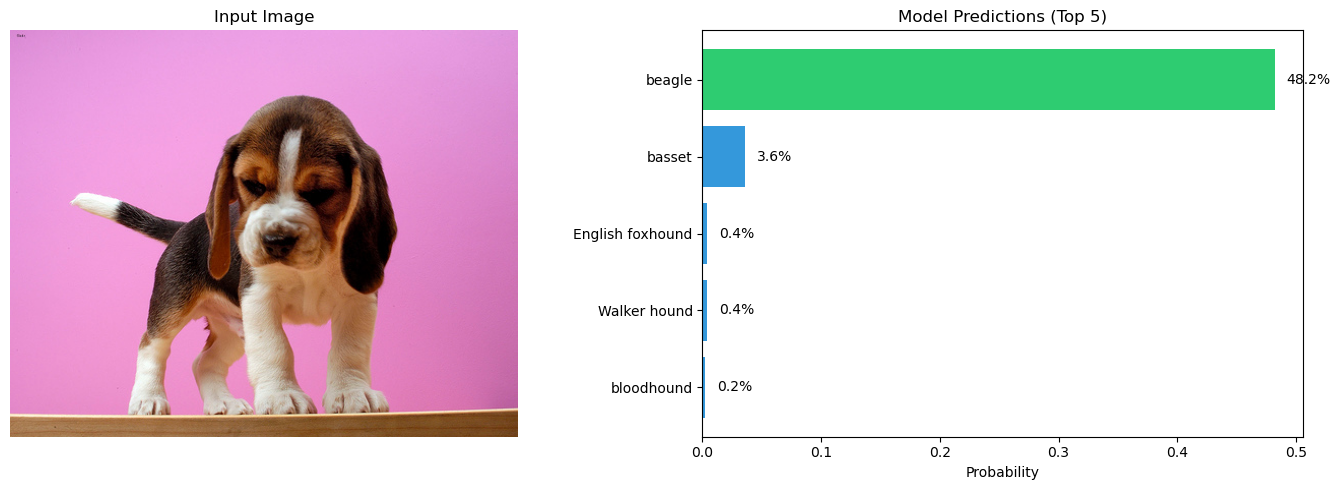


Top prediction: beagle (48.2% confidence)


In [18]:
# Step 4: Classify a single image in detail
test_image = '/data/datasets/oxford_pets/images/beagle_1.jpg'
img, predictions = classify_image(test_image)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Show image
axes[0].imshow(img)
axes[0].axis('off')
axes[0].set_title('Input Image', fontsize=12)

# Show predictions as bar chart
labels = [p[0] for p in predictions]
probs = [p[1] for p in predictions]
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(5)]
axes[1].barh(range(5), probs, color=colors)
axes[1].set_yticks(range(5))
axes[1].set_yticklabels(labels)
axes[1].set_xlabel('Probability')
axes[1].set_title('Model Predictions (Top 5)', fontsize=12)
axes[1].invert_yaxis()
for i, p in enumerate(probs):
    axes[1].text(p + 0.01, i, f'{p:.1%}', va='center')

plt.tight_layout()
plt.show()

print(f"\nTop prediction: {predictions[0][0]} ({predictions[0][1]:.1%} confidence)")

Classifying 6 Random Pet Images
Bombay_7.jpg: mouse (6%)
Egyptian_Mau_191.jpg: Egyptian cat (43%)
Sphynx_245.jpg: Egyptian cat (20%)


Egyptian_Mau_51.jpg: Egyptian cat (57%)


Abyssinian_116.jpg: Egyptian cat (57%)
Persian_221.jpg: Persian cat (22%)


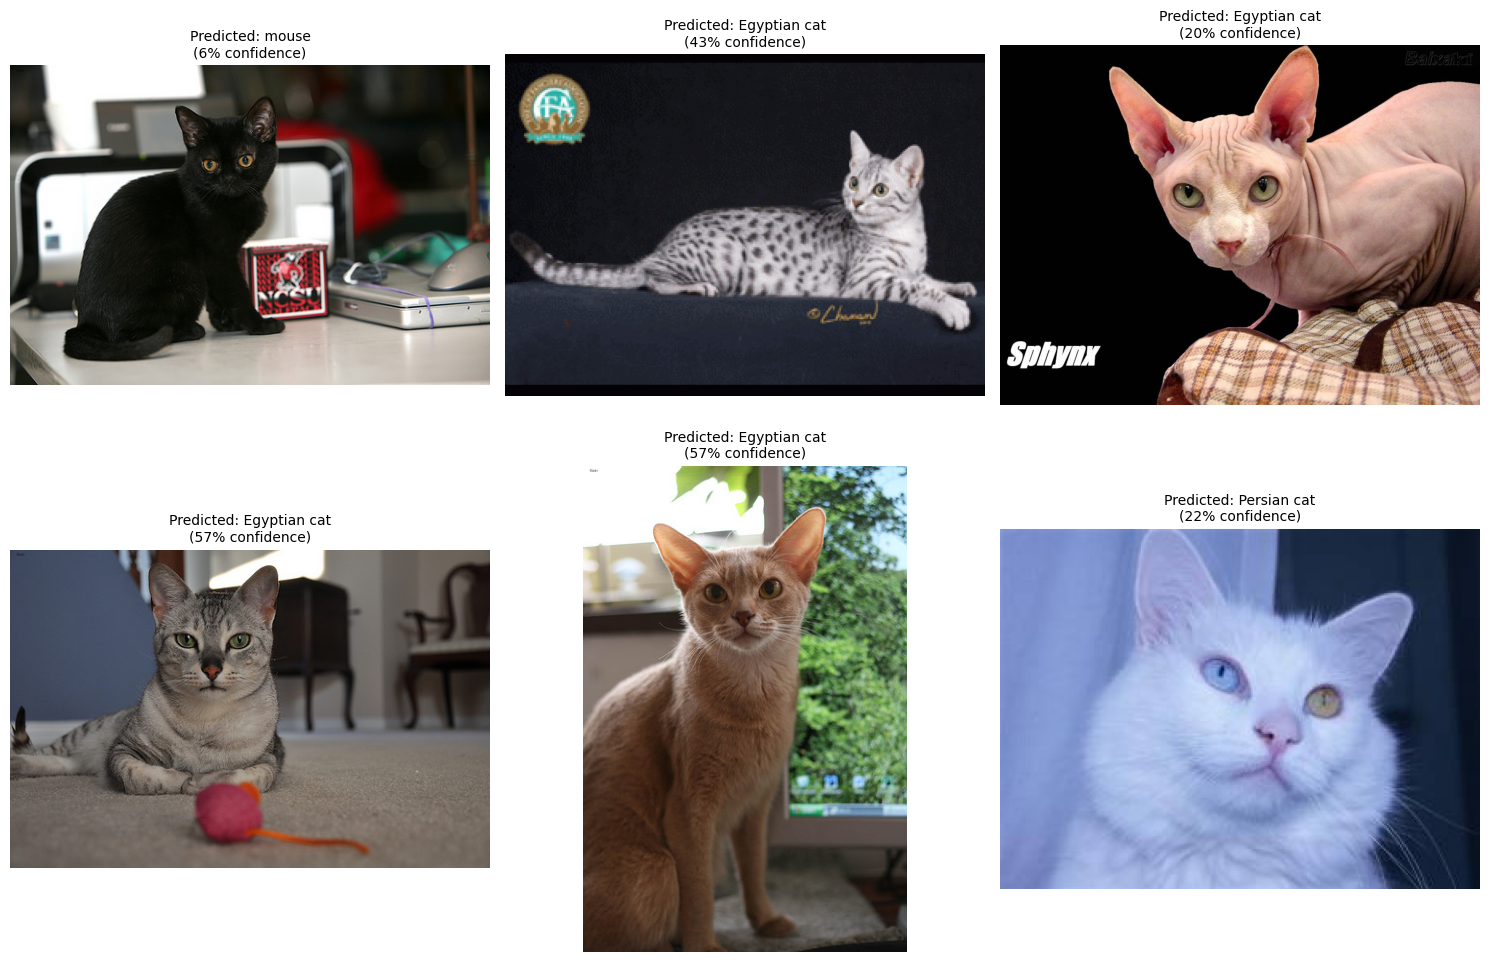

In [19]:
# Step 5: Classify multiple images
import random
random.seed(42)

pets_dir = '/data/datasets/oxford_pets/images'
all_images = [f for f in os.listdir(pets_dir) if f.endswith('.jpg')]
sample_images = random.sample(all_images, 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

print("Classifying 6 Random Pet Images")
print("="*50)

for ax, img_name in zip(axes, sample_images):
    img_path = os.path.join(pets_dir, img_name)
    img, preds = classify_image(img_path)
    
    ax.imshow(img)
    ax.axis('off')
    
    # Format prediction
    pred_label = preds[0][0]
    pred_prob = preds[0][1]
    actual = img_name.rsplit('_', 1)[0].replace('_', ' ').title()
    
    ax.set_title(f'Predicted: {pred_label}\n({pred_prob:.0%} confidence)', fontsize=10)
    print(f"{img_name}: {pred_label} ({pred_prob:.0%})")

plt.tight_layout()
plt.show()

#### Image Classification Summary

Key points:
- **Images are numbers**: Grids of pixel values (150k+ numbers per image)
- **Neural networks learn patterns**: Edges → textures → shapes → objects
- **Transfer learning**: Use pre-trained models instead of starting from scratch
- **Preprocessing matters**: Images must match what the model was trained on

Later in this course, we'll:
- Build our own image classifier with fastai (Lesson 2)
- Understand how neural networks work inside (Lessons 5-6)
- Learn about CNNs — the architecture designed for images (Lessons 10-11)

### Demo 3: Text Understanding (Sentiment Analysis)

Can a computer understand if a movie review is positive or negative? This is **sentiment analysis** — one of the most common NLP tasks.

Modern language models (based on the **Transformer** architecture) can understand context and nuance in ways that were impossible just a few years ago.

In [20]:
from transformers import pipeline

# Load a pre-trained sentiment analysis model
sentiment = pipeline('sentiment-analysis', model='distilbert-base-uncased-finetuned-sst-2-english')

reviews = [
    "This movie was absolutely fantastic! Best film I've seen in years.",
    "Terrible waste of time. The plot made no sense and the acting was wooden.",
    "It was okay. Nothing special, but not bad either.",
    "I went in with low expectations but was pleasantly surprised!",
    "The visuals were stunning but the story felt hollow and predictable.",
]

print("Sentiment Analysis Demo")
print("="*60)

for review in reviews:
    result = sentiment(review)[0]
    emoji = "😊" if result['label'] == 'POSITIVE' else "😞"
    print(f"\n{emoji} {result['label']} ({result['score']:.0%} confidence)")
    display_review = review[:60] + '...' if len(review) > 60 else review
    print(f"   \"{display_review}\"")

Device set to use cuda:0


Sentiment Analysis Demo

😊 POSITIVE (100% confidence)
   "This movie was absolutely fantastic! Best film I've seen in ..."

😞 NEGATIVE (100% confidence)
   "Terrible waste of time. The plot made no sense and the actin..."

😊 POSITIVE (100% confidence)
   "It was okay. Nothing special, but not bad either."

😊 POSITIVE (100% confidence)
   "I went in with low expectations but was pleasantly surprised..."

😞 NEGATIVE (100% confidence)
   "The visuals were stunning but the story felt hollow and pred..."


### Demo 4: Text Generation (LLMs)

Large Language Models (LLMs) like GPT-4, Claude, and LLaMA can generate coherent text, answer questions, write code, and much more.

Here's a tiny local model for demonstration — production LLMs are much more capable.

In [21]:
generator = pipeline('text-generation', model='distilgpt2', max_length=50)

prompts = [
    "Machine learning is",
    "The best way to learn programming is",
]

print("Text Generation Demo (small local model)")
print("="*60)

for prompt in prompts:
    result = generator(prompt, num_return_sequences=1, do_sample=True, temperature=0.7, pad_token_id=50256)
    print(f"\nPrompt: \"{prompt}\"")
    generated = result[0]['generated_text']
    print(f"Output: {generated}")

print("\n(This is a tiny model. Production LLMs like GPT-4/Claude are far more capable.)")
print("Later in this course, we'll work with LLM APIs to build real applications.")

Device set to use cuda:0


Text Generation Demo (small local model)

Prompt: "Machine learning is"
Output: Machine learning is the most important tool we have ever used, and it is a vital tool for learning.



For some, learning has been the most powerful tool for learning, and it is a vital tool for learning.
The following



Prompt: "The best way to learn programming is"
Output: The best way to learn programming is to learn the language and programming you're learning.




For a more complete list of programming languages, check out the full list of programming languages that have been identified.

(This is a tiny model. Production LLMs like GPT-4/Claude are far more capable.)
Later in this course, we'll work with LLM APIs to build real applications.


### Demo Summary

We just saw ML working on three different types of data:

| Data Type | Demo | Technique |
|-----------|------|----------|
| **Tabular** | Titanic survival | Random Forest (tree-based) |
| **Images** | Pet classification | ResNet (neural network) |
| **Text** | Sentiment + generation | Transformers (neural network) |

Different data types, different models, but the same fundamental pattern:
1. Get data with labels
2. Train a model to find patterns
3. Use those patterns on new data

This course will teach you how all of this works.

## Part 7: Core Vocabulary

Before we dive deeper in future lessons, let's establish the key terms:

### Data Terms

| Term | Meaning | Example |
|------|---------|--------|
| **Features** | Input variables | Age, income, pixel values |
| **Labels / Targets** | What we're predicting | Survived/Died, Price, Cat/Dog |
| **Sample / Instance** | One example in the data | One passenger, one image |
| **Dataset** | Collection of samples | 1000 passengers with labels |
| **Training set** | Data used to train the model | 80% of dataset |
| **Validation set** | Data used to tune model | 10% of dataset |
| **Test set** | Data used for final evaluation | 10% of dataset |

### Model Terms

| Term | Meaning |
|------|--------|
| **Model** | The thing that makes predictions |
| **Parameters / Weights** | Numbers inside the model that it learns |
| **Hyperparameters** | Settings you choose (learning rate, # of layers) |
| **Architecture** | The structure of a neural network |

### Training Terms

| Term | Meaning |
|------|--------|
| **Training** | Adjusting weights to fit the data |
| **Inference** | Using trained model to make predictions |
| **Loss function** | Measures how wrong predictions are |
| **Gradient** | Direction to adjust weights |
| **Learning rate** | How big the adjustments are |
| **Epoch** | One pass through all training data |
| **Batch** | Subset of data processed at once |

### Performance Terms

| Term | Meaning |
|------|--------|
| **Accuracy** | % of correct predictions |
| **Overfitting** | Model memorizes training data, fails on new data |
| **Underfitting** | Model too simple, can't capture patterns |
| **Generalization** | Ability to work on new, unseen data |

## Part 8: Where This Course Takes You

Here's the journey ahead:

### Phase 1: Foundations (L1-L4)
- **L1** (today): The big picture of ML
- **L2**: Build your first model with fastai (quick win!)
- **L3**: How models learn (regression, gradient descent)
- **L4**: Classification and neural networks intro

### Phase 2: Neural Networks Deep Dive (L5-L7)
- **L5**: Inside the neural network (forward pass, training loop)
- **L6**: Full tabular ML pipeline
- **L7**: Tree-based models (often beat neural nets on tabular!)

### Phase 3: Images & CNNs (L8-L11)
- **L8**: Neural networks on images
- **L9**: Experimentation and debugging
- **L10-11**: Convolutional Neural Networks

### Phase 4: Production (L12-L13)
- **L12**: Transfer learning (use pretrained models)
- **L13**: Deploy models with FastAPI (you know this!)

### Phase 5: Modern Stack (L14-L19)
- **L14**: Working with LLM APIs
- **L15**: Embeddings and semantic similarity
- **L16**: Vector databases
- **L17-18**: RAG (Retrieval Augmented Generation)
- **L19**: Final project

By the end, you'll be able to:
- Train models on tabular data and images
- Know when to use trees vs neural networks
- Deploy models to production
- Build applications with LLMs and RAG

## Part 9: Key Insights to Remember

Before we wrap up, some wisdom from the field:

### 1. Data > Algorithms
More and better data usually beats a fancier algorithm. Garbage in, garbage out.

### 2. Simple First
Start with simple models (linear regression, random forest). Only add complexity if needed. You'd be surprised how often simple wins.

### 3. The Right Tool for the Job
- **Tabular data**: Trees often beat neural networks
- **Images**: CNNs or Vision Transformers
- **Text**: Transformers / LLMs
- Don't use a sledgehammer when a screwdriver works

### 4. Validation is Everything
Your model's performance on training data means nothing. Only validation/test performance matters.

### 5. ML is Iterative
You won't get it right the first time. Train → Evaluate → Improve → Repeat.

### 6. Deployment is Half the Work
A model in a notebook is useless. Getting it into production, monitoring it, and maintaining it is where the real work begins.

## Summary

Today we covered the ML landscape:

**What ML is:**
- Learning patterns from data to make predictions
- Data + Answers → Rules (instead of writing rules manually)

**Types of ML:**
- Supervised (classification, regression) — our focus
- Unsupervised (clustering, dimensionality reduction)
- Reinforcement learning, self-supervised learning

**Types of data:**
- Tabular, images, text, time series, audio

**Types of models:**
- Linear models (simple but limited)
- Trees (great for tabular)
- Neural networks (great for images/text)

**The workflow:**
- Understand → Prepare → Train → Evaluate → Iterate → Deploy

**Next lesson:** We'll train a real image classifier with fastai and see the entire workflow in action.

<div style="text-align: center; color: #888; font-size: 0.85em; margin-top: 40px; padding-top: 10px; border-top: 1px solid #ddd;">
© 2025 Utvecklarakademin UA Aktiebolag. All rights reserved.<br>
This material is proprietary and may not be reproduced, distributed, or shared without written permission.
</div>